In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv


In [4]:
df = pd.read_csv('/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv')

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 12


In [7]:
# Check missing values

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
# Statistical summary

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# Summary statistics for numerical columns

summary = df[['Age', 'Fare', 'SibSp', 'Parch']].describe()

display(summary)

,Age,Fare,SibSp,Parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [10]:
# Median values

print("Median values:")
print(df[['Age', 'Fare', 'SibSp', 'Parch']].median())

Median values:
Age      28.0000
Fare     14.4542
SibSp     0.0000
Parch     0.0000
dtype: float64


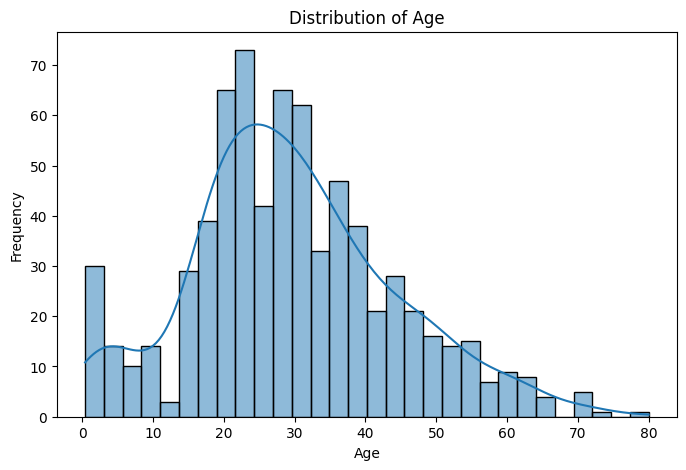

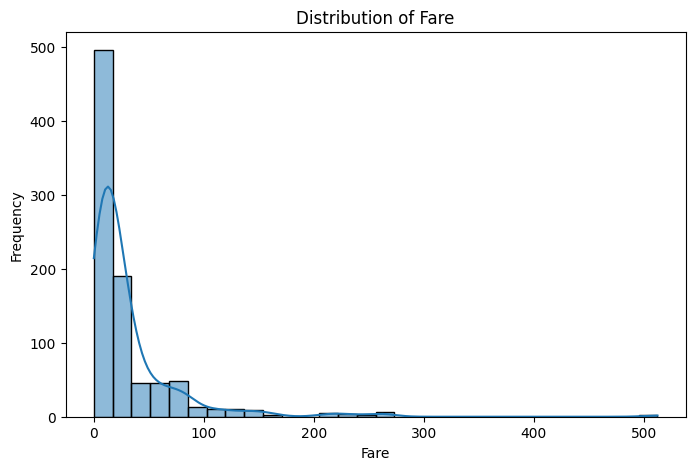

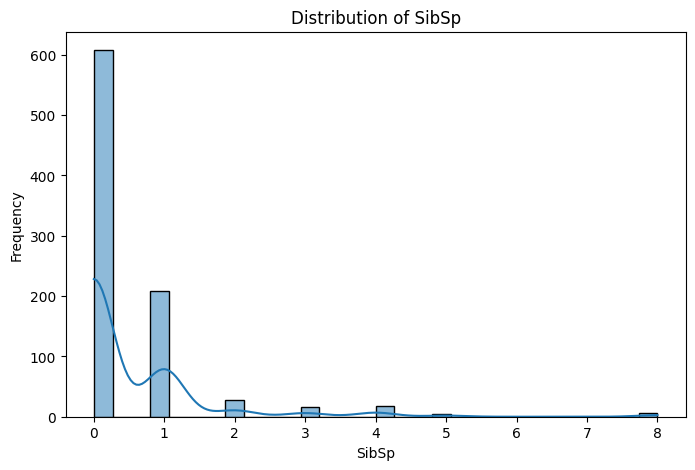

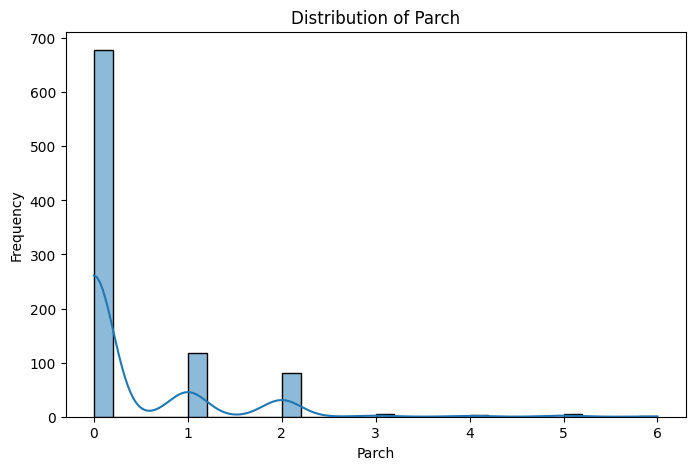

In [11]:
# Histograms of numerical features

numerical_columns = ['Age', 'Fare', 'SibSp', 'Parch']

for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, bins=30, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

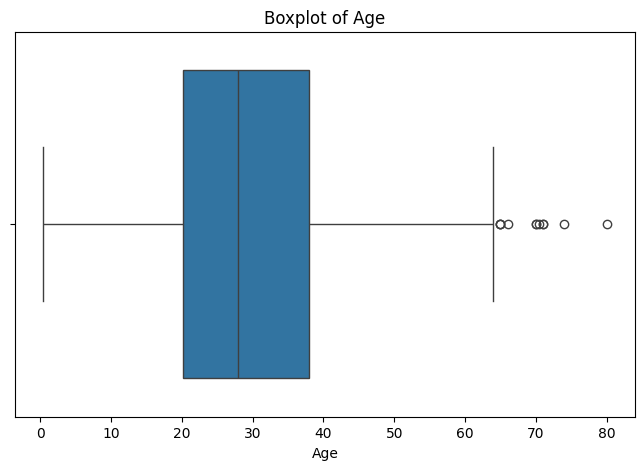

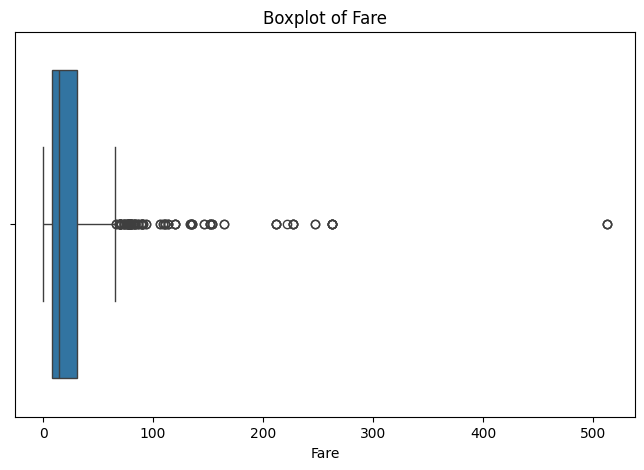

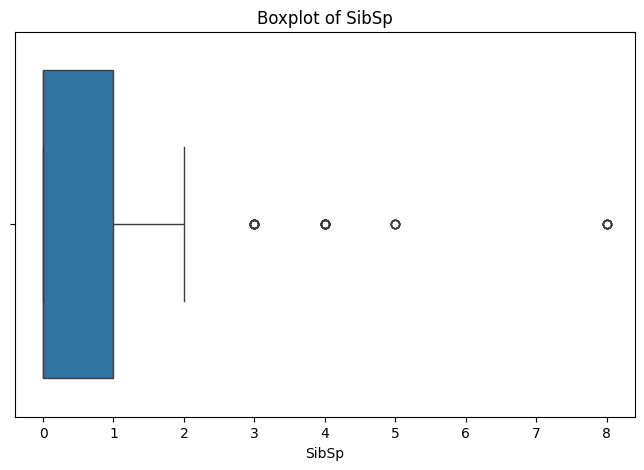

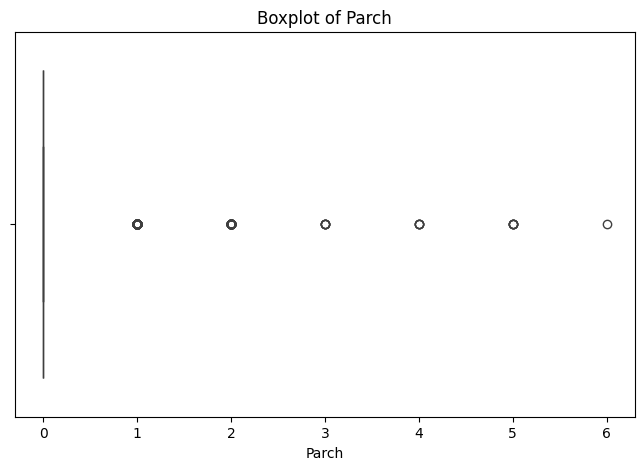

In [12]:
# Boxplots for numerical features

for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

In [13]:
# Correlation matrix

correlation = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()

display(correlation)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


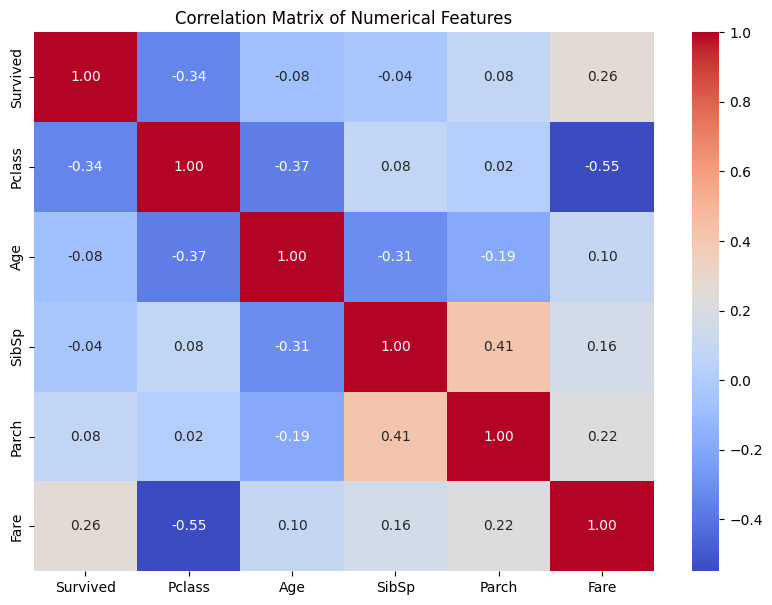

In [14]:
# Correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Features')
plt.show()

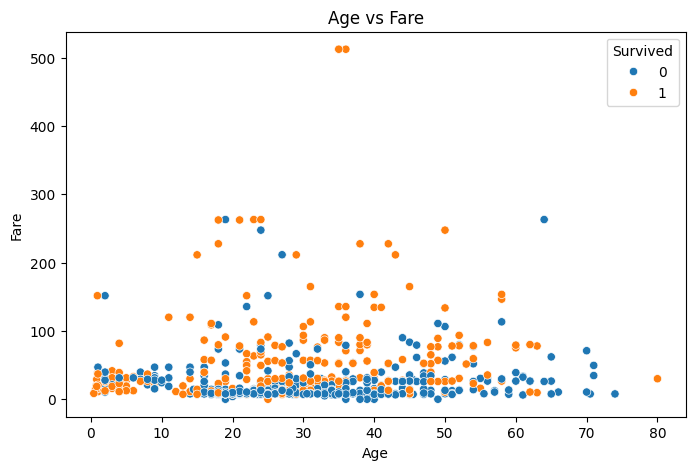

In [15]:
# Scatterplot: Age vs Fare

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Fare',
    hue='Survived'
)

plt.title('Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

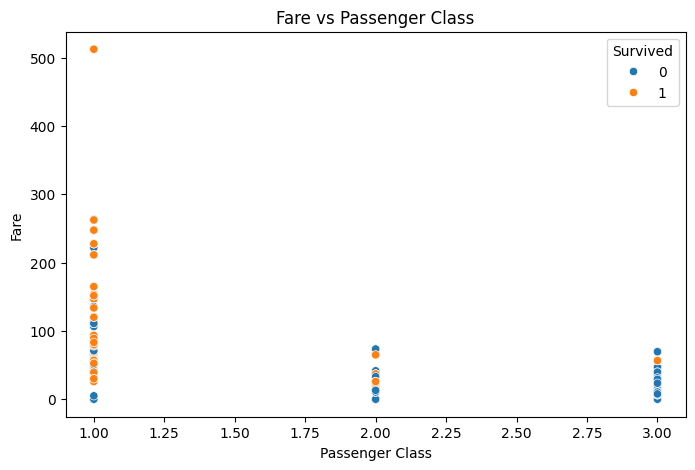

In [16]:
# Scatterplot: Fare vs Passenger Class

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Pclass',
    y='Fare',
    hue='Survived'
)

plt.title('Fare vs Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

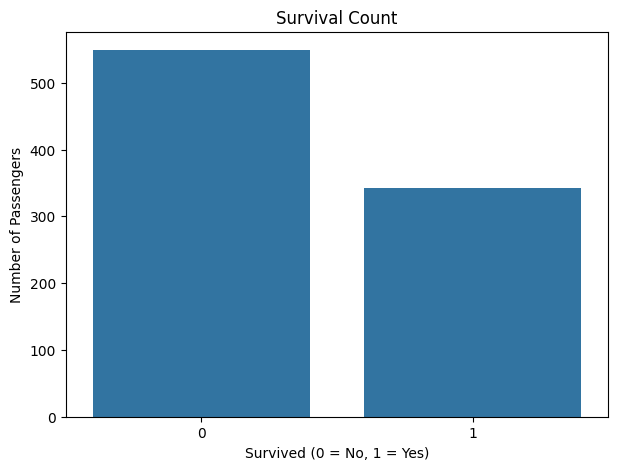

In [17]:
# Survival count

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Survived')

plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

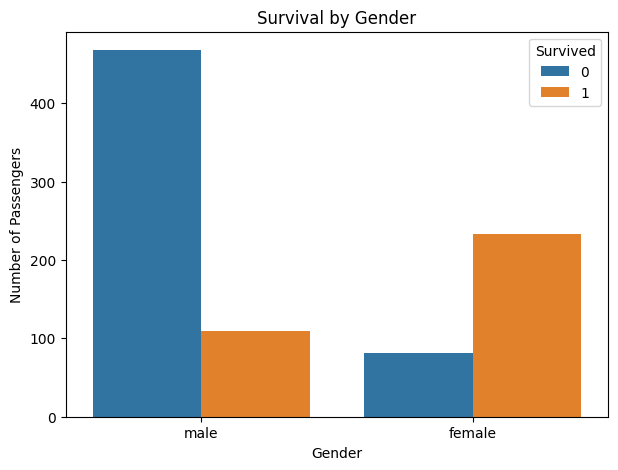

In [18]:
# Survival by gender

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Sex', hue='Survived')

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()

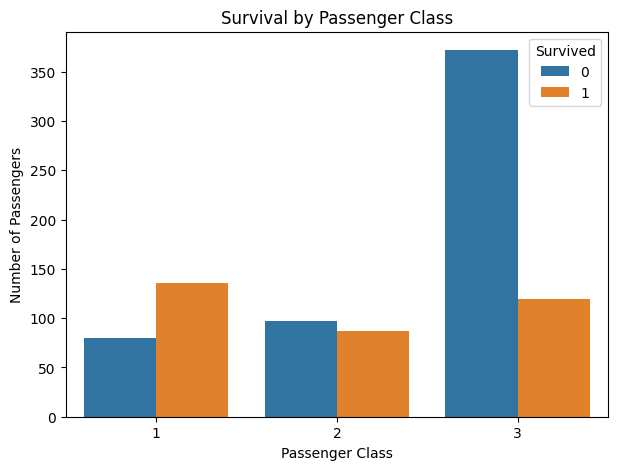

In [19]:
# Survival by passenger class

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Pclass', hue='Survived')

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

In [20]:
# Survival rate by gender

gender_survival = df.groupby('Sex')['Survived'].mean() * 100

print("Survival Rate by Gender:")
print(gender_survival)

Survival Rate by Gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [21]:
# Survival rate by passenger class

class_survival = df.groupby('Pclass')['Survived'].mean() * 100

print("Survival Rate by Passenger Class:")
print(class_survival)

Survival Rate by Passenger Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


## 9. Basic Feature-Level Inferences from Visuals

### Age
- The Age distribution shows that passengers belong to different age groups, with many passengers concentrated in the young and middle-aged ranges.
- The boxplot shows some potential unusual age values.

### Fare
- The Fare distribution is right-skewed.
- Most passengers paid relatively lower fares, while a smaller number paid very high fares.
- The boxplot shows several potential high-fare outliers.

### SibSp
- Most passengers had zero or a small number of siblings or spouses aboard.
- Higher values occur less frequently.

### Parch
- Most passengers had zero parents or children aboard.
- Higher Parch values are less common.

### Passenger Class
- The dataset contains passengers from three different passenger classes.
- Third-class passengers make up a large portion of the dataset.

### Gender
- The survival visualizations show a noticeable difference between male and female passengers.
- Female passengers generally have a higher survival rate than male passengers.

### Survival and Passenger Class
- The survival-rate analysis indicates differences in survival across passenger classes.
- Higher passenger classes generally have better survival rates than lower passenger classes.

### Correlation and Relationships
- The correlation heatmap helps identify relationships between numerical features.
- Scatterplots help visualize relationships and identify unusual observations.

## 10. Patterns, Trends and Anomalies

### Patterns and Trends
- Gender is an important feature when analyzing passenger survival.
- Passenger class is also associated with survival outcomes.
- Fare varies considerably between passengers and contains some high-value observations.
- Most passengers had relatively low values of SibSp and Parch.

### Anomalies
- The boxplots indicate potential outliers, particularly in the Fare feature.
- Some passengers paid substantially higher fares than most other passengers.
- Missing values are present in Age, Cabin, and Embarked and should be considered when preparing the data for further analysis.

## 11. Key Insights

1. The Titanic dataset contains both numerical and categorical features.
2. Age contains missing values and has a varied distribution.
3. Fare is strongly right-skewed and contains potential outliers.
4. Most passengers had few or no siblings, spouses, parents, or children aboard.
5. Survival differs noticeably by gender.
6. Survival also differs across passenger classes.
7. Visualizations such as histograms, boxplots, heatmaps, and scatterplots make these patterns easier to understand.

## 12. Conclusion

Exploratory Data Analysis was performed on the Titanic dataset using summary statistics and visualizations.

Histograms were used to understand numerical feature distributions, while boxplots helped identify potential outliers. Correlation analysis and scatterplots were used to investigate relationships between numerical features. Survival analysis was also performed based on gender and passenger class.

The analysis revealed important patterns related to survival, passenger class, gender, fare, and other numerical features. These findings provide a useful understanding of the dataset before applying machine learning algorithms.